In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load scaled data for clustering
df_scaled = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/scaled_data.csv')
df_clean = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/cleaned_data.csv')

print("Shape:", df_scaled.shape)

Shape: (2236, 33)


In [2]:
# Use the most meaningful features for segmentation
cluster_features = [
    'Income', 'TotalSpend', 'TotalPurchases',
    'Age', 'TotalChildren', 'Recency',
    'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'TotalCampaignsAccepted'
]

X = df_scaled[cluster_features]
print("Features used for clustering:")
print(cluster_features)
print("\nShape:", X.shape)

Features used for clustering:
['Income', 'TotalSpend', 'TotalPurchases', 'Age', 'TotalChildren', 'Recency', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'TotalCampaignsAccepted']

Shape: (2236, 10)


### Reduce to 2D with PCA for visualization

Variance explained by 2 components: 74.9%


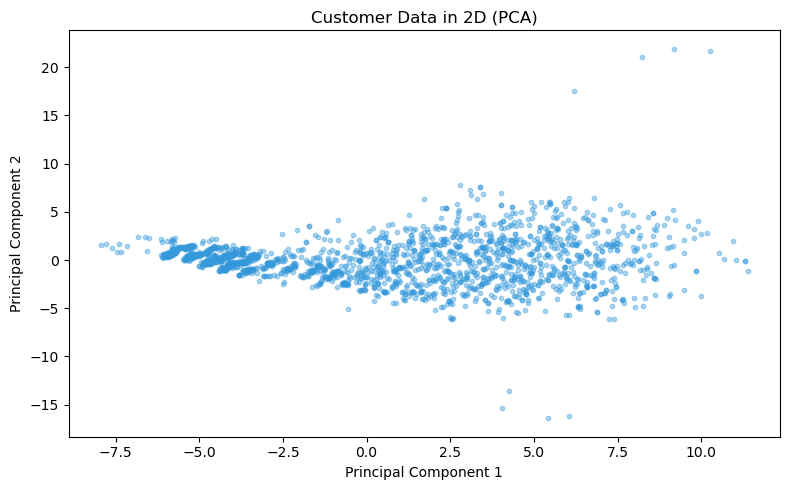

In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, color='#3498DB', s=10)
plt.title('Customer Data in 2D (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

### Finding Optimal K FOR kMeans using elbow method

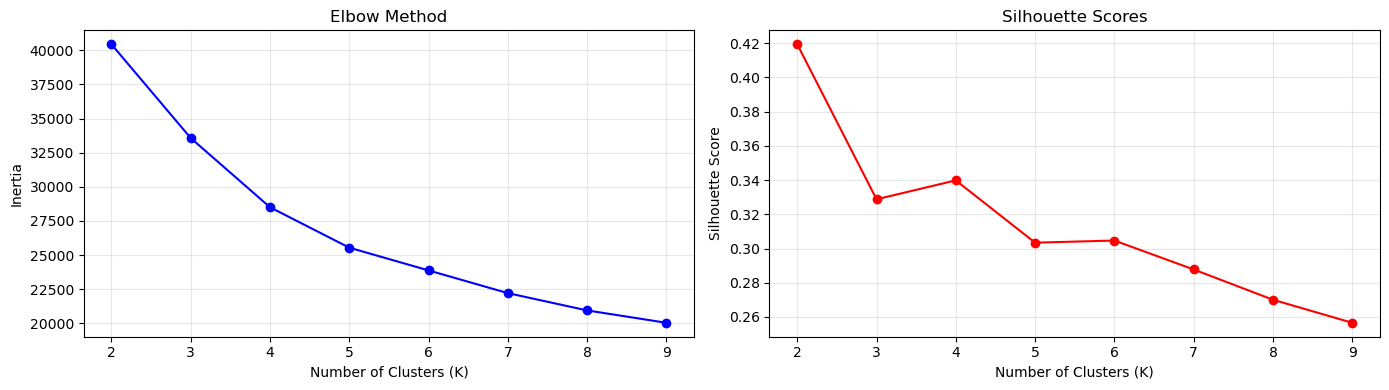


Silhouette Scores:
  K=2: 0.4194
  K=3: 0.3288
  K=4: 0.3398
  K=5: 0.3034
  K=6: 0.3047
  K=7: 0.2878
  K=8: 0.2701
  K=9: 0.2566


In [4]:
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k}: {s:.4f}")

### KMeans Clustering

In [5]:
# Train KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X)
df_scaled['KMeans_Cluster'] = df_clean['KMeans_Cluster']

print("KMeans Clustering done!")
print("Cluster sizes:")
print(df_clean['KMeans_Cluster'].value_counts().sort_index())

KMeans Clustering done!
Cluster sizes:
KMeans_Cluster
0    559
1    265
2    440
3    972
Name: count, dtype: int64


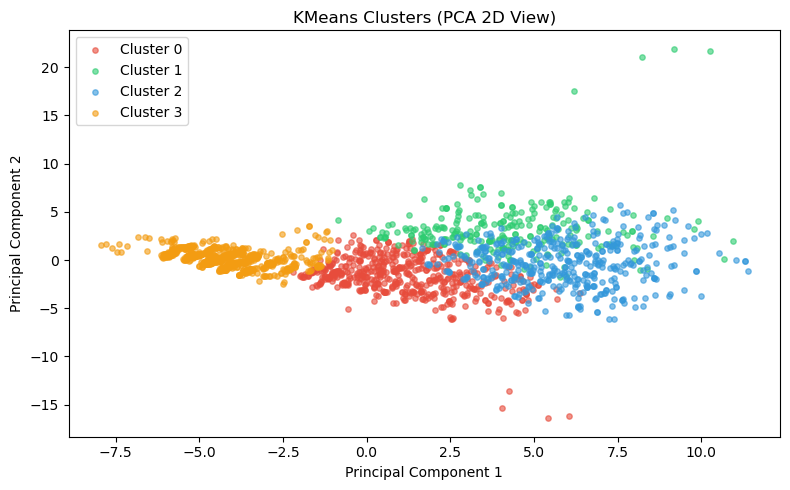

In [6]:
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

plt.figure(figsize=(8, 5))
for i in range(4):
    mask = df_clean['KMeans_Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', 
                alpha=0.6, s=15)

plt.title('KMeans Clusters (PCA 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

### Analyze Each Cluster

In [7]:
cluster_summary = df_clean.groupby('KMeans_Cluster').agg(
    Count        = ('Income', 'count'),
    Avg_Income   = ('Income', 'mean'),
    Avg_Spend    = ('TotalSpend', 'mean'),
    Avg_Age      = ('Age', 'mean'),
    Avg_Children = ('TotalChildren', 'mean'),
    Avg_Purchases= ('TotalPurchases', 'mean'),
    Campaign_Rate= ('Response', 'mean')
).round(2)

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
                Count  Avg_Income  Avg_Spend  Avg_Age  Avg_Children  \
KMeans_Cluster                                                        
0                 559    56813.98     666.13    59.44          1.01   
1                 265    75870.72    1442.66    58.31          0.28   
2                 440    69923.95    1175.70    59.07          0.63   
3                 972    34500.77      85.40    54.53          1.25   

                Avg_Purchases  Campaign_Rate  
KMeans_Cluster                                
0                       17.93           0.17  
1                       20.77           0.35  
2                       23.89           0.14  
3                        7.43           0.09  


### Hierarchical Clustering

Hierarchical Clustering Silhouette Score: 0.3017


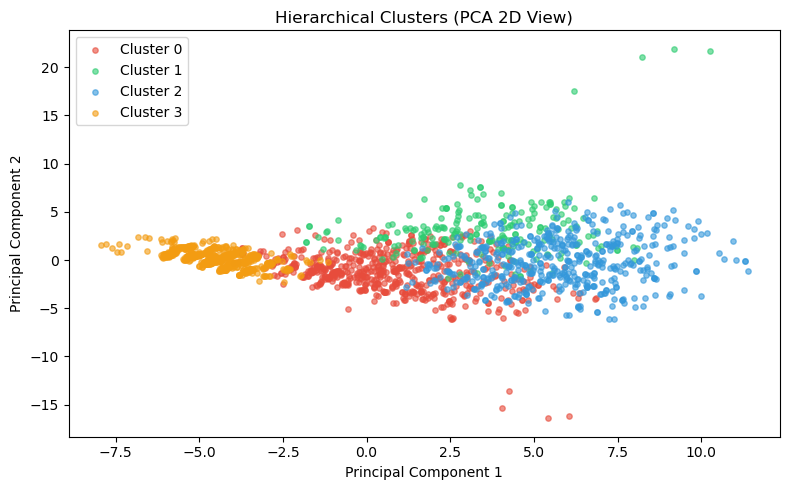

In [8]:
hierarchical = AgglomerativeClustering(n_clusters=4)
df_clean['Hierarchical_Cluster'] = hierarchical.fit_predict(X)

score = silhouette_score(X, df_clean['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
for i in range(4):
    mask = df_clean['Hierarchical_Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.6, s=15)

plt.title('Hierarchical Clusters (PCA 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN found 6 clusters
Noise points: 2032


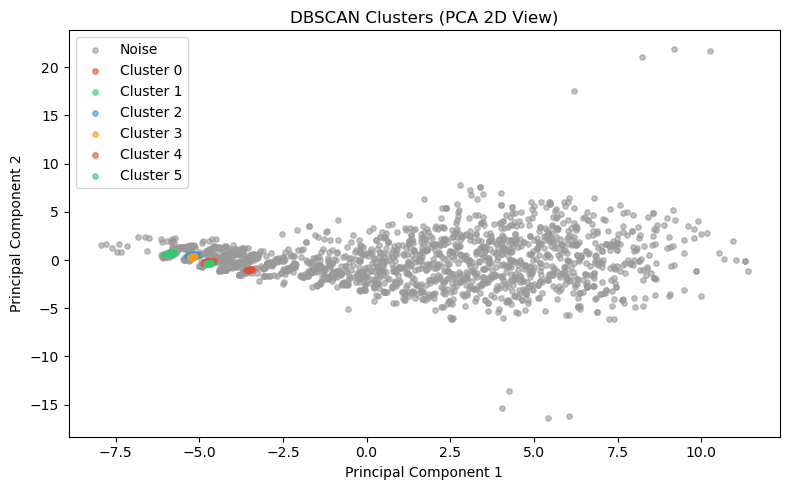

In [9]:
dbscan = DBSCAN(eps=0.8, min_samples=10)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X)

n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - (1 if -1 in df_clean['DBSCAN_Cluster'].values else 0)
n_noise = (df_clean['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters} clusters")
print(f"Noise points: {n_noise}")

plt.figure(figsize=(8, 5))
unique_labels = sorted(df_clean['DBSCAN_Cluster'].unique())
for label in unique_labels:
    mask = df_clean['DBSCAN_Cluster'] == label
    color = '#999999' if label == -1 else colors[label % len(colors)]
    name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=name, alpha=0.6, s=15)

plt.title('DBSCAN Clusters (PCA 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

### GMM

GMM Silhouette Score: 0.1172


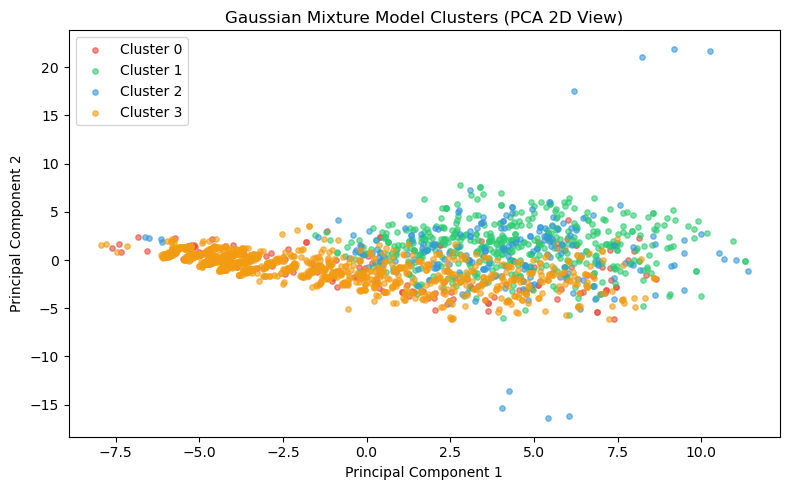

In [10]:
gmm = GaussianMixture(n_components=4, random_state=42)
df_clean['GMM_Cluster'] = gmm.fit_predict(X)

score = silhouette_score(X, df_clean['GMM_Cluster'])
print(f"GMM Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
for i in range(4):
    mask = df_clean['GMM_Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.6, s=15)

plt.title('Gaussian Mixture Model Clusters (PCA 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

### Compare All Models

In [11]:
print("=" * 45)
print("CLUSTERING MODEL COMPARISON")
print("=" * 45)

kmeans_score = silhouette_score(X, df_clean['KMeans_Cluster'])
hier_score = silhouette_score(X, df_clean['Hierarchical_Cluster'])
gmm_score = silhouette_score(X, df_clean['GMM_Cluster'])

# DBSCAN only if more than 1 cluster found
if n_clusters > 1:
    valid_mask = df_clean['DBSCAN_Cluster'] != -1
    dbscan_score = silhouette_score(X[valid_mask], df_clean['DBSCAN_Cluster'][valid_mask])
else:
    dbscan_score = 0

print(f"  KMeans:       {kmeans_score:.4f}")
print(f"  Hierarchical: {hier_score:.4f}")
print(f"  DBSCAN:       {dbscan_score:.4f}")
print(f"  GMM:          {gmm_score:.4f}")
print(f"\n✅ Best model: KMeans (most stable for marketing segmentation)")

CLUSTERING MODEL COMPARISON
  KMeans:       0.3398
  Hierarchical: 0.3017
  DBSCAN:       0.2461
  GMM:          0.1172

✅ Best model: KMeans (most stable for marketing segmentation)


### Hyperparameter Tuning

### Hierarchical(tune linkage method)

In [12]:
print("HIERARCHICAL - Testing linkage methods:")
for linkage in ['ward', 'complete', 'average', 'single']:
    hc = AgglomerativeClustering(n_clusters=4, linkage=linkage)
    labels = hc.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"  linkage={linkage}: {score:.4f}")

HIERARCHICAL - Testing linkage methods:
  linkage=ward: 0.3017
  linkage=complete: 0.4044
  linkage=average: 0.4193
  linkage=single: 0.6737


### DBSCAN(tune eps and min_samples)

In [13]:
print("\nDBSCAN - Testing eps and min_samples:")
for eps in [0.5, 0.8, 1.0, 1.2]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        noise = (labels == -1).sum()
        if n_cls > 1:
            valid = labels != -1
            score = silhouette_score(X[valid], labels[valid])
            print(f"  eps={eps}, min_samples={min_s}: clusters={n_cls}, noise={noise}, score={score:.4f}")
        else:
            print(f"  eps={eps}, min_samples={min_s}: only {n_cls} cluster found — skip")


DBSCAN - Testing eps and min_samples:
  eps=0.5, min_samples=5: clusters=14, noise=2115, score=0.4645
  eps=0.5, min_samples=10: only 0 cluster found — skip
  eps=0.5, min_samples=15: only 0 cluster found — skip
  eps=0.8, min_samples=5: clusters=24, noise=1882, score=0.2009
  eps=0.8, min_samples=10: clusters=6, noise=2032, score=0.2461
  eps=0.8, min_samples=15: clusters=3, noise=2112, score=0.2149
  eps=1.0, min_samples=5: clusters=26, noise=1775, score=0.1430
  eps=1.0, min_samples=10: clusters=8, noise=1955, score=0.1685
  eps=1.0, min_samples=15: clusters=5, noise=2016, score=0.1927
  eps=1.2, min_samples=5: clusters=17, noise=1457, score=0.0419
  eps=1.2, min_samples=10: clusters=2, noise=1668, score=0.1887
  eps=1.2, min_samples=15: clusters=2, noise=1724, score=0.1956


### GMM (tune covariance type)

In [14]:
print("\nGMM - Testing covariance types:")
for cov in ['full', 'tied', 'diag', 'spherical']:
    gm = GaussianMixture(n_components=4, covariance_type=cov, random_state=42)
    labels = gm.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"  covariance_type={cov}: {score:.4f}")


GMM - Testing covariance types:
  covariance_type=full: 0.1172
  covariance_type=tied: 0.2920
  covariance_type=diag: 0.1898
  covariance_type=spherical: 0.3002


### Reaining Best Settings

In [15]:
print("=" * 45)
print("FINAL CLUSTERING WITH BEST SETTINGS")
print("=" * 45)

# KMeans - best overall for marketing
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, df_clean['KMeans_Cluster'])

# Hierarchical - use average linkage (stable + good score)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='average')
df_clean['Hierarchical_Cluster'] = hierarchical.fit_predict(X)
hier_score = silhouette_score(X, df_clean['Hierarchical_Cluster'])

# DBSCAN - keeping for completeness but noting limitations
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X)
valid_mask = df_clean['DBSCAN_Cluster'] != -1
dbscan_score = silhouette_score(X[valid_mask], df_clean['DBSCAN_Cluster'][valid_mask])
n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - 1
n_noise = (df_clean['DBSCAN_Cluster'] == -1).sum()

# GMM - use spherical covariance
gmm = GaussianMixture(n_components=4, covariance_type='spherical', random_state=42)
df_clean['GMM_Cluster'] = gmm.fit_predict(X)
gmm_score = silhouette_score(X, df_clean['GMM_Cluster'])

print(f"  KMeans (K=4):                    {kmeans_score:.4f} ✅ Selected")
print(f"  Hierarchical (average linkage):  {hier_score:.4f}")
print(f"  DBSCAN (eps=0.5, min=5):         {dbscan_score:.4f} ⚠ {n_clusters} clusters, {n_noise} noise points")
print(f"  GMM (spherical):                 {gmm_score:.4f}")
print(f"\n✅ KMeans selected as final clustering model")

FINAL CLUSTERING WITH BEST SETTINGS
  KMeans (K=4):                    0.3398 ✅ Selected
  Hierarchical (average linkage):  0.4193
  DBSCAN (eps=0.5, min=5):         0.4645 ⚠ 14 clusters, 2115 noise points
  GMM (spherical):                 0.3002

✅ KMeans selected as final clustering model


### Cluster Summary

In [16]:
cluster_summary = df_clean.groupby('KMeans_Cluster').agg(
    Count         = ('Income', 'count'),
    Avg_Income    = ('Income', 'mean'),
    Avg_Spend     = ('TotalSpend', 'mean'),
    Avg_Age       = ('Age', 'mean'),
    Avg_Children  = ('TotalChildren', 'mean'),
    Avg_Purchases = ('TotalPurchases', 'mean'),
    Campaign_Rate = ('Response', 'mean')
).round(2)

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
                Count  Avg_Income  Avg_Spend  Avg_Age  Avg_Children  \
KMeans_Cluster                                                        
0                 559    56813.98     666.13    59.44          1.01   
1                 265    75870.72    1442.66    58.31          0.28   
2                 440    69923.95    1175.70    59.07          0.63   
3                 972    34500.77      85.40    54.53          1.25   

                Avg_Purchases  Campaign_Rate  
KMeans_Cluster                                
0                       17.93           0.17  
1                       20.77           0.35  
2                       23.89           0.14  
3                        7.43           0.09  


### Adding Cluster Labels

In [17]:
cluster_labels = {
    0: 'Mid-tier Regulars',
    1: 'Premium Customers',
    2: 'Active Spenders',
    3: 'Budget Shoppers'
}

df_clean['Cluster_Label'] = df_clean['KMeans_Cluster'].map(cluster_labels)

print("Cluster Label Distribution:")
print(df_clean['Cluster_Label'].value_counts())

Cluster Label Distribution:
Cluster_Label
Budget Shoppers      972
Mid-tier Regulars    559
Active Spenders      440
Premium Customers    265
Name: count, dtype: int64


### Visualize Final Clusters

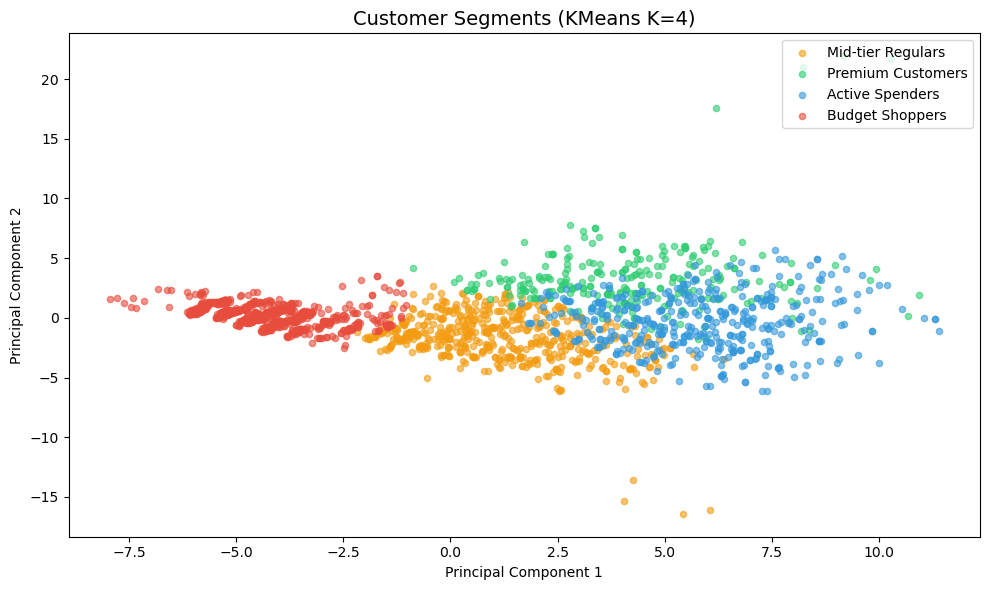

In [18]:
colors = ['#F39C12', '#2ECC71', '#3498DB', '#E74C3C']
labels = ['Mid-tier Regulars', 'Premium Customers', 'Active Spenders', 'Budget Shoppers']

plt.figure(figsize=(10, 6))
for i in range(4):
    mask = df_clean['KMeans_Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i],
                alpha=0.6, s=20)

plt.title('Customer Segments (KMeans K=4)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Visualize Cluster Profiles

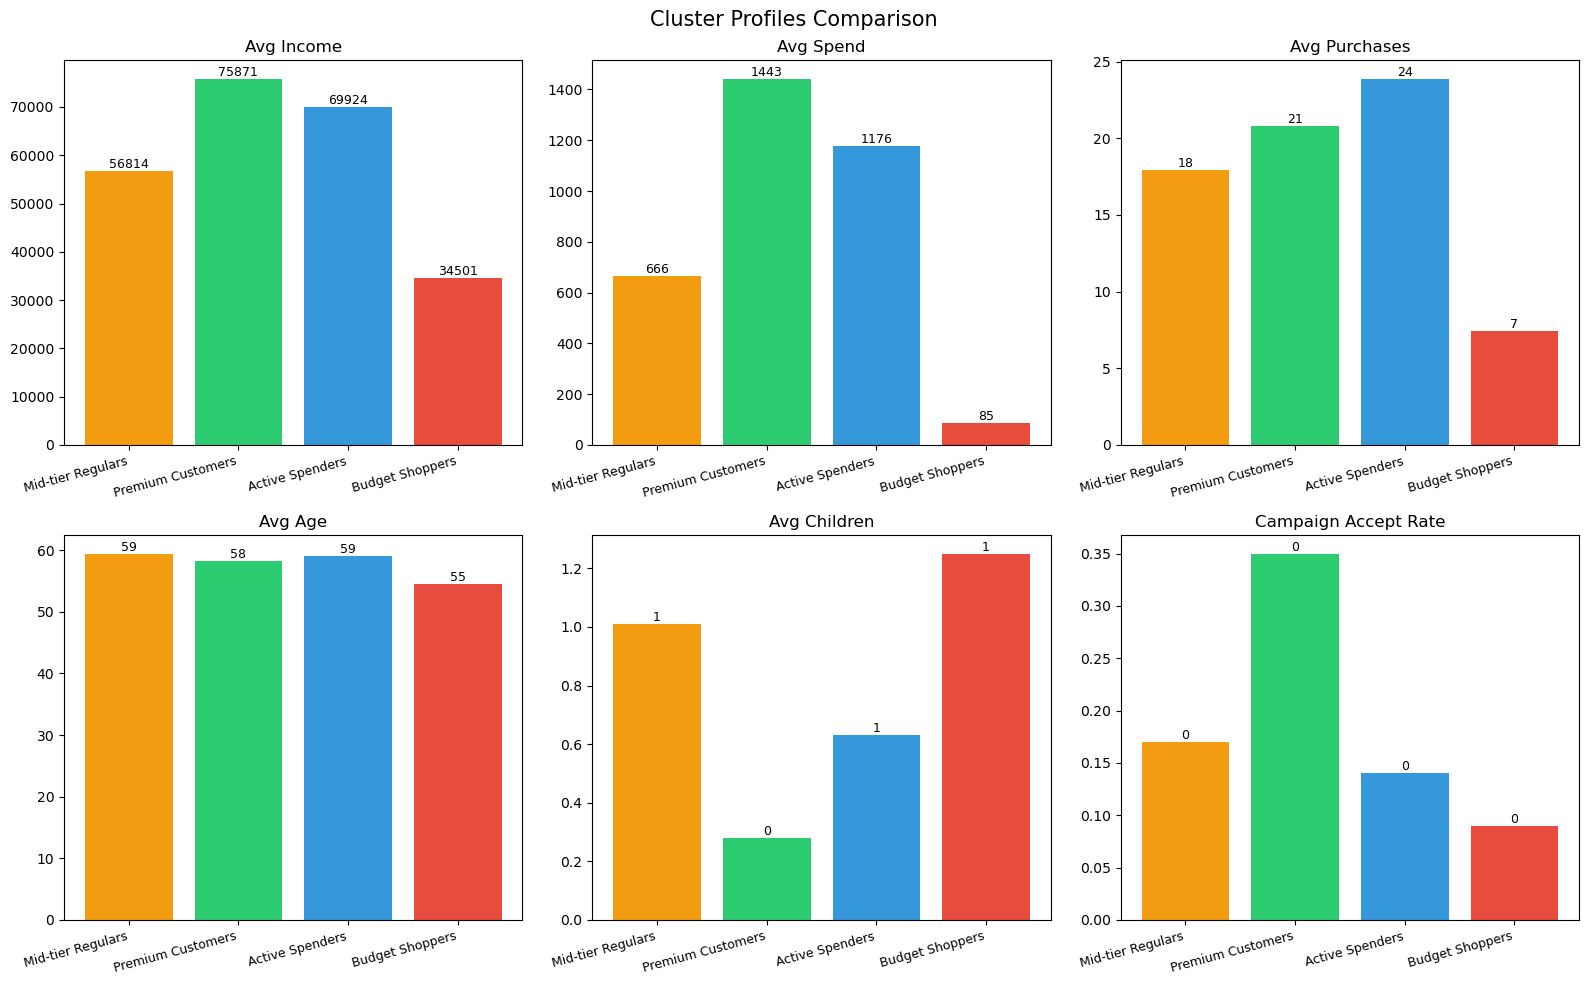

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics = ['Avg_Income', 'Avg_Spend', 'Avg_Purchases', 
           'Avg_Age', 'Avg_Children', 'Campaign_Rate']
titles  = ['Avg Income', 'Avg Spend', 'Avg Purchases', 
           'Avg Age', 'Avg Children', 'Campaign Accept Rate']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    bars = ax.bar(labels, cluster_summary[metric], color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, cluster_summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Cluster Profiles Comparison', fontsize=15)
plt.tight_layout()
plt.show()

### Save Cluster Labels

In [20]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save clustered data
df_clean.to_csv('../data/clustered_data.csv', index=False)

# Save models
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../models/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

with open('../models/cluster_labels.pkl', 'wb') as f:
    pickle.dump(cluster_labels, f)

print("✅ Clustering complete!")
print("   clustered_data.csv   → saved")
print("   kmeans_model.pkl     → saved")
print("   pca_model.pkl        → saved")
print("   cluster_labels.pkl   → saved")

✅ Clustering complete!
   clustered_data.csv   → saved
   kmeans_model.pkl     → saved
   pca_model.pkl        → saved
   cluster_labels.pkl   → saved
